# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración opcional de visualización
sns.set_theme(style="whitegrid")
%matplotlib inline

# Modelado (si aplica más adelante)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()


,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


user_id           0
date              0
landing           0
region            0
dispositivo       0
traffic_source    0
user_type         0
converted         0
gasto             0
dtype: int64

✍️ **Comentario**:
El dataset tiene 40,000 filas y 9 columnas, sin ningún valor nulo en ninguna columna.
La columna date es de tipo object y debería ser datetime; se recomienda convertirla con pd.to_datetime(df['date']) para habilitar análisis temporales.
Las columnas converted (int64) y gasto (float64) tienen el tipo de dato correcto.
El resto de columnas categóricas (landing, region, dispositivo, traffic_source, user_type) son object, lo cual es esperado para variables de texto.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
# Verificar usuarios únicos
print(f"Total de filas: {len(df)}")
print(f"Usuarios únicos: {df['user_id'].nunique()}")
print(f"Duplicados: {df['user_id'].duplicated().sum()}")

Total de filas: 40000
Usuarios únicos: 40000
Duplicados: 0


 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df[df["converted"] == 1]["gasto"].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df["landing"].value_counts())


Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64


✍️ **Comentario**: Diagnóstico de variables categóricas — landing

La columna landing contiene únicamente las categorías A y B, que son exactamente los grupos esperados del experimento A/B.
La distribución es prácticamente equitativa: B = 20,018 y A = 19,982, con una diferencia de solo 36 registros (~0.09%).
No se detectan categorías mal escritas, valores inesperados ni errores de codificación.

✅ La variable landing está correcta y lista para el análisis.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df[df["landing"] == "A"]["gasto"]
gasto_B = df[df["landing"] == "B"]["gasto"]

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(19982, 20018)

### Prueba ...

**Hipótesis:**
- Hipótesis nula (H₀): El gasto promedio de los usuarios convertidos es igual en la página A y en la página B.

- Hipótesis alternativa (H₁): El gasto promedio de los usuarios convertidos es diferente entre la página A y la página B.


In [ ]:
from scipy import stats

# Aplicar prueba
gasto_A_conv = df[(df["landing"] == "A") & (df["converted"] == 1)]["gasto"]
gasto_B_conv = df[(df["landing"] == "B") & (df["converted"] == 1)]["gasto"]

stat, p_value = stats.ttest_ind(gasto_A_conv, gasto_B_conv, equal_var=False)

# Visualizar resultados
print(f"Estadístico : {stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.48101092267275
Valor p: 3.627602231521493e-21


### 📝 Conclusión e interpretación

**Decisión:**
- Con un valor p de 3.63e-21, que es extremadamente menor a 0.05, se rechaza la hipótesis nula. Existe una diferencia estadísticamente significativa en el gasto promedio entre los usuarios convertidos de la página A y la página B.
Interpretación de negocio:

- El estadístico negativo (-9.48) indica que el gasto promedio de los usuarios convertidos en la página A es menor que en la página B. Es decir, la página B no solo convierte usuarios, sino que genera un mayor valor económico por cliente. Desde el punto de vista del negocio, implementar la página B como versión definitiva sería la decisión más rentable, ya que los clientes que llegan por ella tienden a gastar más.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

In [ ]:
# Número de usuarios convertidos por página
convertidos = df.groupby("landing")["converted"].sum()

# Total de usuarios por página
totales = df.groupby("landing")["converted"].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [ ]:
from scipy.stats import chi2_contingency

# Aplicar prueba
tabla = [[2512, 19982 - 2512],
         [3194, 20018 - 3194]]

stat, p_value, dof, expected = chi2_contingency(tabla)

# Visualizar resultados
print(f"Estadístico : {stat}")
print(f"Valor p: {p_value}")

Estadístico : 93.37483168026097
Valor p: 4.327184295434882e-22


### 📝 Conclusión e interpretación

- **Decisión:**
Se rechaza la hipótesis nula. Con un valor p de 4.33e-22, muy por debajo del umbral de 0.05, existe evidencia estadísticamente significativa de que la tasa de conversión es diferente entre la página A y la página B.

- **Interpretación de negocio:**
La página B presenta una tasa de conversión notablemente superior a la página A (15.96% vs 12.57%). Esto significa que por cada 100 usuarios expuestos, la página B convierte aproximadamente 3 clientes más que la página A. Dado que la diferencia no es atribuible al azar, el negocio debería considerar adoptar la página B como versión definitiva para maximizar el número de usuarios que se convierten en clientes.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula**(H₀): La tasa de conversión es independiente de la fuente de tráfico; es decir, el canal por el que llega el usuario no influye en si convierte o no.

- **Hipótesis alternativa** (H₁): Existe una asociación entre la fuente de tráfico y la conversión; es decir, algunos canales generan mayor tasa de conversión que otros.


In [ ]:
from scipy.stats import chi2_contingency


In [ ]:
# Aplicar prueba
tabla_trafico = pd.crosstab(df["traffic_source"], df["converted"])

stat, p_value, dof, expected = chi2_contingency(tabla_trafico)

# Visualizar resultados
print(f"Estadístico : {stat}")
print(f"Valor p: {p_value}")
print(f"Grados de libertad: {dof}")
print("\nTabla de contingencia:\n", tabla_trafico)



Estadístico : 8.662108841397938
Valor p: 0.0341375947833914
Grados de libertad: 3

Tabla de contingencia:
 converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


### 📝 Conclusión e interpretación

- **Decisión:**
Se rechaza la hipótesis nula. Con un valor p de 0.034, menor a 0.05, existe una asociación estadísticamente significativa entre la fuente de tráfico y la tasa de conversión.

- **Interpretación de negocio:**
Aunque en volumen absoluto Organic genera más conversiones (2,480), su tasa de conversión es la más baja (13.79%). Por otro lado, Email es el canal más eficiente con la mayor tasa de conversión (14.75%) a pesar de tener un volumen medio. Ads tiene el mayor volumen de usuarios y una tasa competitiva (14.69%), lo que lo convierte en un canal de alto impacto. Referral es el canal con menor volumen y menor tasa de conversión (13.88%). En conclusión, si el objetivo es maximizar conversiones, invertir en Email y Ads ofrece el mejor rendimiento por usuario alcanzado.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión
Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula** (H₀): La tasa de conversión es independiente del tipo de usuario; es decir, si el usuario es nuevo o recurrente no influye en si convierte o no.

- **Hipótesis alternativa** (H₁): Existe una asociación entre el tipo de usuario y la conversión; es decir, algún perfil de usuario presenta mayor probabilidad de conversión que otro.

In [ ]:
from scipy.stats import chi2_contingency


In [ ]:
# Aplicar prueba
tabla_user_type = pd.crosstab(df["user_type"], df["converted"])

stat, p_value, dof, expected = chi2_contingency(tabla_user_type)

# Visualizar resultados
print(f"Estadístico : {stat}")
print(f"Valor p: {p_value}")
print(f"Grados de libertad: {dof}")
print("\nTabla de contingencia:\n", tabla_user_type)

Estadístico : 0.5134849494478645
Valor p: 0.4736341272301974
Grados de libertad: 1

Tabla de contingencia:
 converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


### 📝 Conclusión e interpretación

- **Decisión:**
No se rechaza la hipótesis nula. Con un valor p de 0.474, muy superior al umbral de 0.05, no hay evidencia estadísticamente significativa de que el tipo de usuario esté asociado con la conversión.

- **Interpretación de negocio:**
Las tasas de conversión entre usuarios nuevos (14.28%) y recurrentes (14.09%) son prácticamente idénticas, lo que confirma que el tipo de usuario no influye en la probabilidad de convertir. Para el negocio esto significa que no vale la pena segmentar las estrategias de conversión por este criterio, ya que ambos perfiles responden de manera similar a la campaña.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

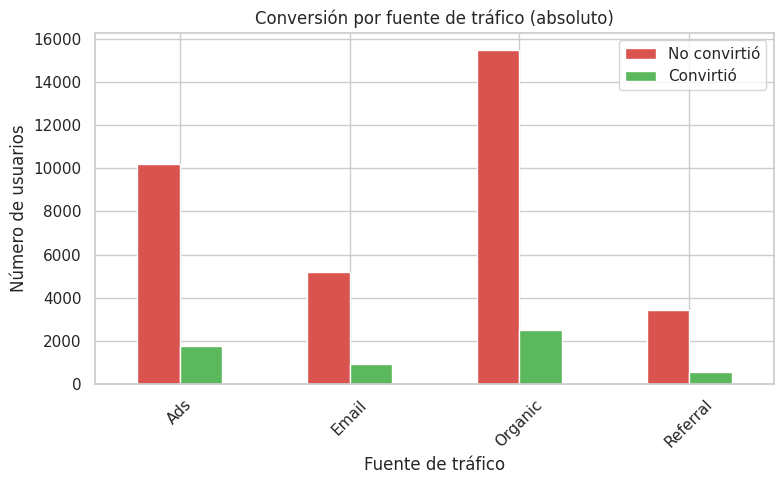

In [ ]:
# Gráfica de cantidades absolutas
tabla_trafico = pd.crosstab(df["traffic_source"], df["converted"])

tabla_trafico.plot(kind="bar", figsize=(8, 5), color=["#d9534f", "#5cb85c"])
plt.title("Conversión por fuente de tráfico (absoluto)")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Número de usuarios")
plt.xticks(rotation=45)
plt.legend(["No convirtió", "Convirtió"])
plt.tight_layout()
plt.show()


La primera gráfica muestra las cantidades absolutas de usuarios por canal. Organic domina en volumen total de usuarios y conversiones absolutas (2,480), seguido de Ads (1,759) y Email (918). Sin embargo, el volumen alto no necesariamente implica mayor eficiencia.

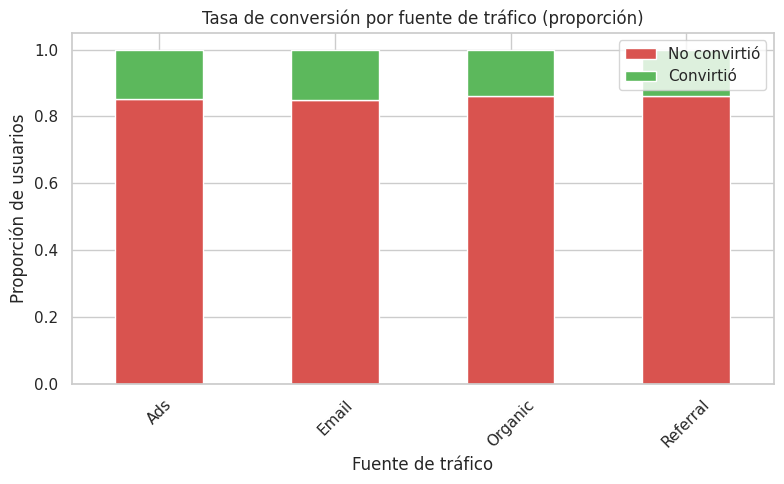

In [ ]:
# Gráfica de proporciones
tabla_trafico_norm = pd.crosstab(df["traffic_source"], df["converted"], normalize="index")

tabla_trafico_norm.plot(kind="bar", stacked=True, figsize=(8, 5), color=["#d9534f", "#5cb85c"])
plt.title("Tasa de conversión por fuente de tráfico (proporción)")
plt.xlabel("Fuente de tráfico")
plt.ylabel("Proporción de usuarios")
plt.xticks(rotation=45)
plt.legend(["No convirtió", "Convirtió"])
plt.tight_layout()
plt.show()

La segunda gráfica de proporciones revela la historia real: las diferencias en tasa de conversión entre canales son muy pequeñas visualmente, lo que es consistente con el valor p de 0.034 — significativo pero con un efecto moderado. Email y Ads muestran una franja verde ligeramente mayor que Organic y Referral, confirmando que son los canales más eficientes en proporción.
En resumen: Organic gana en volumen, pero Email y Ads ganan en eficiencia de conversión.

### Relación entre el tipo de usuario y la conversión

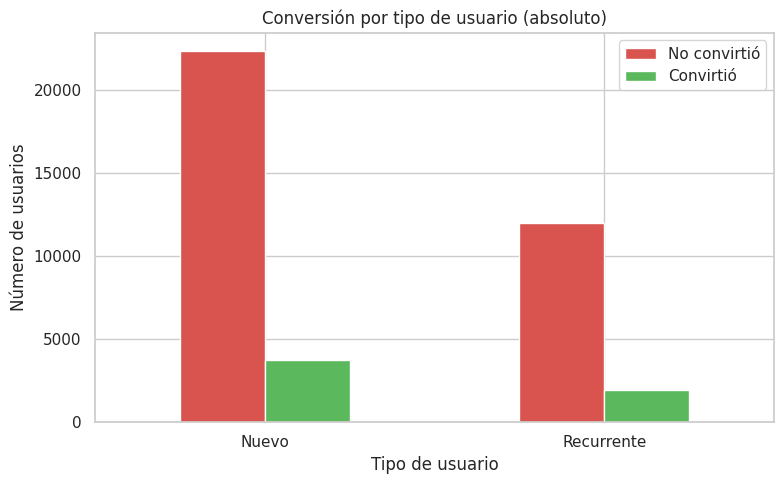

In [ ]:
# Gráfica de cantidades absolutas
tabla_user = pd.crosstab(df["user_type"], df["converted"])

tabla_user.plot(kind="bar", figsize=(8, 5), color=["#d9534f", "#5cb85c"])
plt.title("Conversión por tipo de usuario (absoluto)")
plt.xlabel("Tipo de usuario")
plt.ylabel("Número de usuarios")
plt.xticks(rotation=0)
plt.legend(["No convirtió", "Convirtió"])
plt.tight_layout()
plt.show()

La primera gráfica muestra que los usuarios Nuevos dominan en volumen absoluto (3,738 conversiones) frente a los Recurrentes (1,968), simplemente porque hay más usuarios nuevos en el dataset.

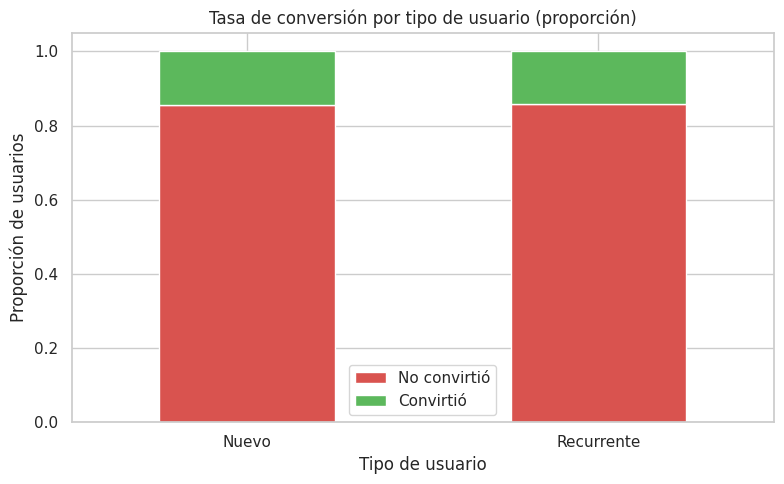

In [ ]:
tabla_user_norm = pd.crosstab(df["user_type"], df["converted"], normalize="index")

tabla_user_norm.plot(kind="bar", stacked=True, figsize=(8, 5), color=["#d9534f", "#5cb85c"])
plt.title("Tasa de conversión por tipo de usuario (proporción)")
plt.xlabel("Tipo de usuario")
plt.ylabel("Proporción de usuarios")
plt.xticks(rotation=0)
plt.legend(["No convirtió", "Convirtió"])
plt.tight_layout()
plt.show()

La segunda gráfica de proporciones confirma lo que la prueba Chi-cuadrado ya indicaba: las barras apiladas son prácticamente idénticas entre ambos tipos de usuario, con una tasa de conversión de ~14.28% para Nuevos y ~14.09% para Recurrentes.
En resumen: el tipo de usuario no influye en la probabilidad de conversión. Ambos perfiles se comportan de manera casi idéntica, por lo que no es una variable útil para segmentar estrategias de conversión.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  

**¿Qué página genera mayor conversión y gasto promedio?**
La página B es superior en ambas métricas. Presenta una tasa de conversión del 15.96% frente al 12.57% de la página A, y los usuarios convertidos en B gastan en promedio más que los de A. Ambas diferencias son estadísticamente significativas (p < 0.05), por lo que se recomienda adoptar la página B como versión definitiva.

**¿Qué canales de tráfico son más efectivos para generar conversiones?**
Email y Ads son los canales más eficientes en tasa de conversión (14.75% y 14.69% respectivamente), mientras que Organic y Referral se quedan por debajo (13.79% y 13.88%). Sin embargo, Organic genera el mayor volumen absoluto de conversiones. La diferencia entre canales es estadísticamente significativa (p = 0.034), por lo que vale la pena priorizar Email y Ads para maximizar la eficiencia.

**¿Existen diferencias significativas según el tipo de usuario?**
No. La prueba Chi-cuadrado no encontró diferencias significativas (p = 0.474) entre usuarios nuevos (14.28%) y recurrentes (14.09%). El tipo de usuario no es un factor determinante en la conversión, por lo que no se justifica segmentar estrategias por este criterio.

**¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?**

1 Implementar la página B como versión definitiva, ya que genera más conversiones y mayor gasto por cliente.
2 Incrementar la inversión en Email y Ads, priorizando eficiencia sobre volumen.
3 Revisar la estrategia de Organic, que aunque genera mucho tráfico, tiene la tasa de conversión más baja.
4 No segmentar campañas por tipo de usuario, ya que nuevos y recurrentes convierten a tasas prácticamente idénticas.

### 🌟 Insight Ejecutivo basado en el Experimento A/B

🔍 **Comparación de página (A vs B)**

**Gasto promedio por usuario que convirtió:**
- La página B genera un gasto promedio mayor que la página A entre los usuarios que convirtieron.
- La diferencia es estadísticamente significativa (T-test de Welch, estadístico = -9.48, p = 3.63e-21).
- **Interpretación:** La página B no solo atrae más conversiones, sino que los clientes que convierte tienden a gastar más, lo que la hace superior en valor económico por usuario.

**Tasa de conversión:**
- La página A convirtió el 12.57% de sus usuarios (2,512 de 19,982) y la página B convirtió el 15.96% (3,194 de 20,018).
- La diferencia es estadísticamente significativa (Chi-cuadrado = 93.37, p = 4.33e-22).
- **Interpretación:** Por cada 100 usuarios expuestos, la página B convierte aproximadamente 3 clientes más que la página A. Esto representa un impacto directo y relevante en los ingresos del negocio.

---

📊 **Segmentación por fuente de tráfico**

- Email y Ads presentan las tasas de conversión más altas (14.75% y 14.69%), mientras que Organic y Referral se quedan por debajo (13.79% y 13.88%). La diferencia es estadísticamente significativa (Chi-cuadrado = 8.66, p = 0.034).
- **Interpretación:** Aunque Organic genera el mayor volumen absoluto de usuarios, su eficiencia de conversión es la más baja. Email y Ads son los canales más rentables por usuario alcanzado y deben priorizarse en la estrategia de inversión.

---

📊 **Segmentación por tipo de usuario**

- Las tasas de conversión entre usuarios nuevos (14.28%) y recurrentes (14.09%) son prácticamente idénticas. No existe diferencia estadísticamente significativa (Chi-cuadrado = 0.51, p = 0.474).
- **Interpretación:** El historial previo del usuario no influye en su probabilidad de convertir. No se justifica segmentar ni personalizar estrategias de conversión basándose en este criterio.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

💡 **Recomendaciones de negocio:**

- Adoptar la página B como versión definitiva, dado que supera a la página A tanto en tasa de conversión como en gasto promedio por cliente.
- Incrementar la inversión en los canales Email y Ads, priorizando eficiencia de conversión sobre volumen de tráfico.
- Revisar y optimizar la estrategia de contenido Organic para mejorar su tasa de conversión, aprovechando el alto volumen de usuarios que ya atrae.
- No segmentar campañas por tipo de usuario (nuevo vs recurrente), ya que ambos perfiles responden de manera equivalente a las acciones de marketing.